In [1]:
import pandas as pd
import numpy as np

In [12]:
rng = np.random.default_rng(1)

mi1 = pd.MultiIndex.from_product(
    [["A1", "A2"], [2025, 2026]], names=["property", "year"])
mi2 = pd.MultiIndex.from_product(
    [["B1", "B2", "B3"], ["jan", "feb"]], names=["shop", "month"])

data = rng.random((4, 6))
df = pd.DataFrame(data, index=mi1, columns=mi2)
print(df)

# by index
print(df['B2'])
print(df['B2', 'feb'])

# by slice
print(df.iloc[1:, 2:5])
print(df.loc[:, 'B1'])
print(df.loc[:, ('B1', 'jan')])

ind1 = pd.IndexSlice[:,2025]
ind2 = pd.IndexSlice[:,'jan']
print(df.loc[ind1, ind2])

print(df)

shop                 B1                  B2                  B3          
month               jan       feb       jan       feb       jan       feb
property year                                                            
A1       2025  0.511822  0.950464  0.144160  0.948649  0.311831  0.423326
         2026  0.827703  0.409199  0.549594  0.027559  0.753513  0.538143
A2       2025  0.329732  0.788429  0.303195  0.453498  0.134042  0.403113
         2026  0.203455  0.262313  0.750365  0.280409  0.485191  0.980737
month               jan       feb
property year                    
A1       2025  0.144160  0.948649
         2026  0.549594  0.027559
A2       2025  0.303195  0.453498
         2026  0.750365  0.280409
property  year
A1        2025    0.948649
          2026    0.027559
A2        2025    0.453498
          2026    0.280409
Name: (B2, feb), dtype: float64
shop                 B2                  B3
month               jan       feb       jan
property year                      

In [15]:
data = {
    ("A1", 2025): 1,
    ("A1", 2026): 2,
    ("A1", 2027): 3,
    ("A2", 2025): 11,
    ("A2", 2026): 12,
    ("A2", 2027): 13,
    ("A3", 2025): 21,
    ("A3", 2026): 22,
    ("A3", 2027): 23,}
sr = pd.Series(data)
sr.index.names = ["property", "year"]
print(sr)

# по нескольким индексам
print(sr['A1'])
print(sr['A1', 2027])
print(sr[:, 2027])

print(sr.loc['A2':'A3', 2025:2026])
print(sr[sr>12])
print(sr.loc[['A1','A3'], 2025:2026])

property  year
A1        2025     1
          2026     2
          2027     3
A2        2025    11
          2026    12
          2027    13
A3        2025    21
          2026    22
          2027    23
dtype: int64
year
2025    1
2026    2
2027    3
dtype: int64
3
property
A1     3
A2    13
A3    23
dtype: int64
property  year
A2        2025    11
          2026    12
A3        2025    21
          2026    22
dtype: int64
property  year
A2        2027    13
A3        2025    21
          2026    22
          2027    23
dtype: int64
property  year
A1        2025     1
          2026     2
A3        2025    21
          2026    22
dtype: int64


In [20]:
index = pd.MultiIndex.from_product([['a','b','c'],[1, 2]])
data = pd.Series(rng.random(6), index=index)
print(data)

index = pd.MultiIndex.from_product([['a','c','b'],[1, 2]])
data = pd.Series(rng.random(6), index=index)
print(data)
# print(data['a':'b'])
data = data.sort_index()
print(data)
print(data['a':'b'])

a  1    0.215218
   2    0.639331
b  1    0.805055
   2    0.963671
c  1    0.150525
   2    0.482212
dtype: float64
a  1    0.894716
   2    0.422717
c  1    0.589502
   2    0.024491
b  1    0.673460
   2    0.919089
dtype: float64
a  1    0.894716
   2    0.422717
b  1    0.673460
   2    0.919089
c  1    0.589502
   2    0.024491
dtype: float64
a  1    0.894716
   2    0.422717
b  1    0.673460
   2    0.919089
dtype: float64


In [28]:
data = {
    ("A1", 2025, 1): 1,
    ("A1", 2025, 2): 2,
    ("A1", 2026, 1): 3,
    ("A1", 2026, 2): 4,
    ("A1", 2027, 1): 5,
    ("A1", 2027, 2): 6,
    ("A2", 2025, 1): 11,
    ("A2", 2025, 2): 12,
    ("A2", 2026, 1): 13,
    ("A2", 2026, 2): 14,
    ("A2", 2027, 1): 15,
    ("A2", 2027, 2): 16,
    ("A3", 2025, 1): 21,
    ("A3", 2025, 2): 22,
    ("A3", 2026, 1): 23,
    ("A3", 2026, 2): 24,
    ("A3", 2027, 1): 25,
    ("A3", 2027, 2): 26,}

sr = pd.Series(data)
print(sr)

# перегруппировка индекса
print(sr.unstack())
print(sr.unstack(level=2))
print(sr.unstack(level=1))
print(sr.unstack(level=0))

A1  2025  1     1
          2     2
    2026  1     3
          2     4
    2027  1     5
          2     6
A2  2025  1    11
          2    12
    2026  1    13
          2    14
    2027  1    15
          2    16
A3  2025  1    21
          2    22
    2026  1    23
          2    24
    2027  1    25
          2    26
dtype: int64
          1   2
A1 2025   1   2
   2026   3   4
   2027   5   6
A2 2025  11  12
   2026  13  14
   2027  15  16
A3 2025  21  22
   2026  23  24
   2027  25  26
          1   2
A1 2025   1   2
   2026   3   4
   2027   5   6
A2 2025  11  12
   2026  13  14
   2027  15  16
A3 2025  21  22
   2026  23  24
   2027  25  26
      2025  2026  2027
A1 1     1     3     5
   2     2     4     6
A2 1    11    13    15
   2    12    14    16
A3 1    21    23    25
   2    22    24    26
        A1  A2  A3
2025 1   1  11  21
     2   2  12  22
2026 1   3  13  23
     2   4  14  24
2027 1   5  15  25
     2   6  16  26


In [33]:
sr.index.names = ["product", "year", "count"]
print(sr)

df = sr.reset_index(name='value')
print(df)
print(type(df))

print(df.set_index('product'))
print(df.set_index(['product','count']))

product  year  count
A1       2025  1         1
               2         2
         2026  1         3
               2         4
         2027  1         5
               2         6
A2       2025  1        11
               2        12
         2026  1        13
               2        14
         2027  1        15
               2        16
A3       2025  1        21
               2        22
         2026  1        23
               2        24
         2027  1        25
               2        26
dtype: int64
   product  year  count  value
0       A1  2025      1      1
1       A1  2025      2      2
2       A1  2026      1      3
3       A1  2026      2      4
4       A1  2027      1      5
5       A1  2027      2      6
6       A2  2025      1     11
7       A2  2025      2     12
8       A2  2026      1     13
9       A2  2026      2     14
10      A2  2027      1     15
11      A2  2027      2     16
12      A3  2025      1     21
13      A3  2025      2     22
14      A3  202

In [39]:
# сводные таблицы

import seaborn as sns

# titanic = sns.load_dataset("titanic")
#
# print(type(titanic))
# print(titanic.head())
#
# print(titanic.groupby('sex')['survived'].mean())
# print(titanic.groupby(['sex', 'class'])['survived'].mean().unstack())

In [41]:
births = pd.read_csv('/Users/adil.murat/PycharmProjects/ml_formula/data/births.csv')
print(births.head())

births['decade'] =10 * (births["year"] // 10)
print(births.head())

print(births.pivot_table("births", index='decade', columns='gender', aggfunc='sum'))

   year  month  day gender  births
0  1969      1  1.0      F    4046
1  1969      1  1.0      M    4440
2  1969      1  2.0      F    4454
3  1969      1  2.0      M    4548
4  1969      1  3.0      F    4548
   year  month  day gender  births  decade
0  1969      1  1.0      F    4046    1960
1  1969      1  1.0      M    4440    1960
2  1969      1  2.0      F    4454    1960
3  1969      1  2.0      M    4548    1960
4  1969      1  3.0      F    4548    1960
gender         F         M
decade                    
1960     1753634   1846572
1970    16263075  17121550
1980    18310351  19243452
1990    19479454  20420553
2000    18229309  19106428


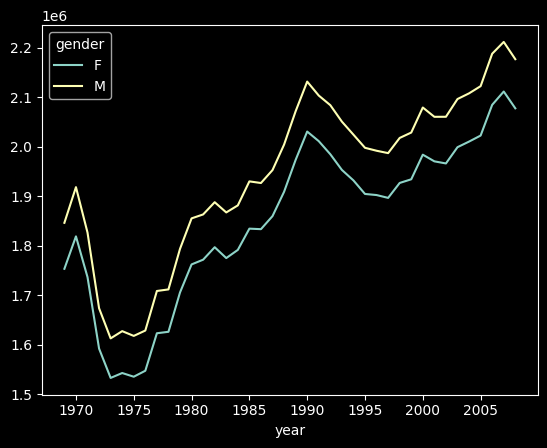

In [52]:
import matplotlib.pyplot as plt

births_years = births.pivot_table("births", index='year', columns='gender', aggfunc='sum')

births_years.plot()
plt.show()


(array([38.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  1.,  4.,  3.,  3.,
        11., 13., 11., 10., 19., 18., 24., 20., 31., 40., 27., 39., 42.,
        33., 41., 41., 58., 31., 43., 31., 31., 21., 19., 21., 24.,  8.,
         2.,  3.,  3.,  1.,  1.,  0.,  0.,  0.,  1.]),
 array([  16.  ,   78.28,  140.56,  202.84,  265.12,  327.4 ,  389.68,
         451.96,  514.24,  576.52,  638.8 ,  701.08,  763.36,  825.64,
         887.92,  950.2 , 1012.48, 1074.76, 1137.04, 1199.32, 1261.6 ,
        1323.88, 1386.16, 1448.44, 1510.72, 1573.  , 1635.28, 1697.56,
        1759.84, 1822.12, 1884.4 , 1946.68, 2008.96, 2071.24, 2133.52,
        2195.8 , 2258.08, 2320.36, 2382.64, 2444.92, 2507.2 , 2569.48,
        

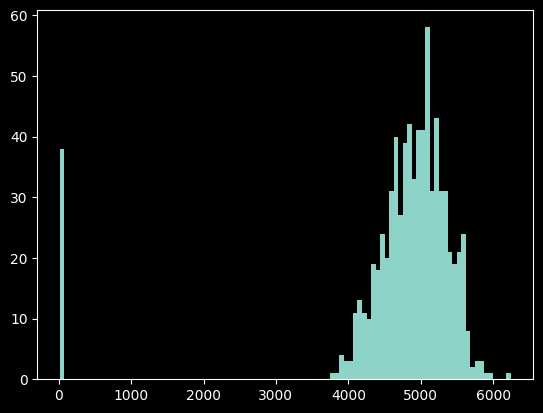

In [53]:
plt.hist(births[births['year'] == 1969]['births'], bins=100)

In [54]:
q = np.percentile(births["births"], [25,50,75])
print(q)
m = q[1]
sig = 0.74 * (q[2]-q[0])

[4358.  4814.  5289.5]
689.31
   year  month  day gender  births  decade
0  1969      1  1.0      F    4046    1960
1  1969      1  1.0      M    4440    1960
2  1969      1  2.0      F    4454    1960
3  1969      1  2.0      M    4548    1960
4  1969      1  3.0      F    4548    1960


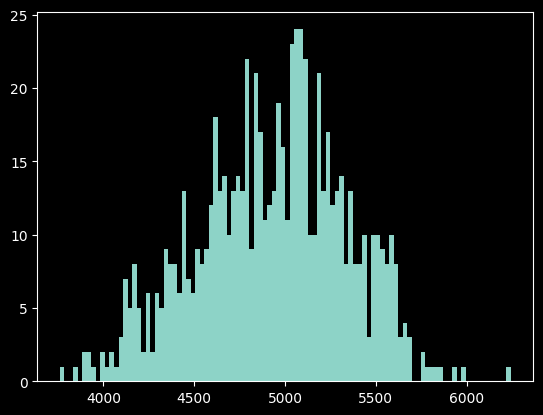

In [55]:
births = births.query("(births > @m - 5*@sig) & (births < @m + 5*@sig)")
plt.hist(births[births['year'] == 1969]['births'], bins=100)
plt.show()

In [80]:
print(births.dtypes)
print(births.index)
births['day'] = births['day'].astype(int)
births.index = pd.to_datetime(births["year"] * 10000 + births["month"] * 100 + births['day'] , format='%Y%m%d')
print(births.index)


year         int64
month        int64
day          int64
gender         str
births       int64
decade       int64
dayofweek    int32
dtype: object
DatetimeIndex(['1969-01-01', '1969-01-01', '1969-01-02', '1969-01-02',
               '1969-01-03', '1969-01-03', '1969-01-04', '1969-01-04',
               '1969-01-05', '1969-01-05',
               ...
               '1988-12-27', '1988-12-27', '1988-12-28', '1988-12-28',
               '1988-12-29', '1988-12-29', '1988-12-30', '1988-12-30',
               '1988-12-31', '1988-12-31'],
              dtype='datetime64[us]', length=14610, freq=None)
DatetimeIndex(['1969-01-01', '1969-01-01', '1969-01-02', '1969-01-02',
               '1969-01-03', '1969-01-03', '1969-01-04', '1969-01-04',
               '1969-01-05', '1969-01-05',
               ...
               '1988-12-27', '1988-12-27', '1988-12-28', '1988-12-28',
               '1988-12-29', '1988-12-29', '1988-12-30', '1988-12-30',
               '1988-12-31', '1988-12-31'],
          

            year  month  day gender  births  decade  dayofweek
1969-01-01  1969      1    1      F    4046    1960          2
1969-01-01  1969      1    1      M    4440    1960          2
1969-01-02  1969      1    2      F    4454    1960          3
1969-01-02  1969      1    2      M    4548    1960          3
1969-01-03  1969      1    3      F    4548    1960          4


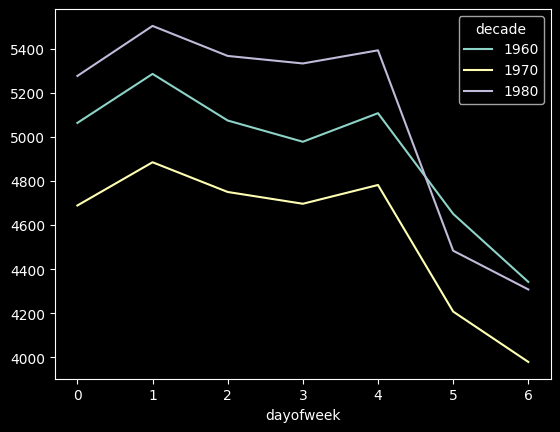

In [81]:
births["dayofweek"] = births.index.dayofweek
print(births.head())

births_dow = births.pivot_table("births", index='dayofweek', columns='decade', aggfunc='mean')

births_dow.plot()
plt.show()

             births
month day          
1     1    4009.225
      2    4247.400
      3    4500.900
      4    4571.350
      5    4603.625


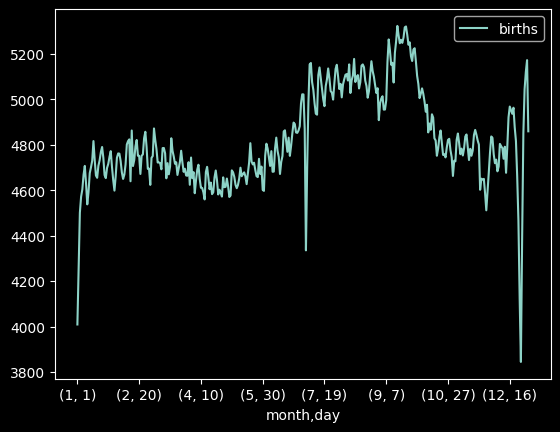

In [82]:
births_dom = births.pivot_table("births", index=[births.month, births.day])
print(births_dom.head())
births_dom.plot()
plt.show()

              births
2012-01-01  4009.225
2012-01-02  4247.400
2012-01-03  4500.900
2012-01-04  4571.350
2012-01-05  4603.625


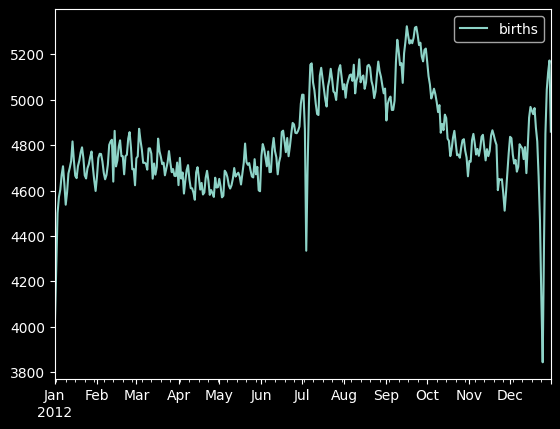

In [83]:
from datetime import datetime
births_dom.index = [datetime(2012, month, day) for (month, day) in births_dom.index]
print(births_dom.head())

births_dom.plot()
plt.show()